In [1]:
import pandas as pd

# File path (data folder in current directory)
file_path = "data/correlation_case_study_MP_1.csv"

# Read CSV into DataFrame
df = pd.read_csv(file_path)

# Preview data
print(df.head())

   Advertising_Spend    Sales  Study_Hours  Exam_Score  Social_Trust  \
0            5596.06  4998.42          3.3        66.1             4   
1            4834.08  4694.20          3.9        80.6             2   
2            5777.23  4344.59          6.5        82.1             3   
3            6827.64  5599.62          6.2        94.8             3   
4            4719.02  4593.97          5.0        74.4             4   

   Voluntary_Associations  
0                     0.0  
1                     0.0  
2                     3.7  
3                     0.9  
4                     6.1  


### Compute summary statistics (mean, median, std) for all numeric columns.

In [2]:
numeric_df = df.select_dtypes(include=['number'])

# Compute summary statistics
summary_stats = pd.DataFrame({
    'Mean': numeric_df.mean(),
    'Median': numeric_df.median(),
    'Std Dev': numeric_df.std()
})

print(summary_stats)

                               Mean   Median      Std Dev
Advertising_Spend       4901.208000  4935.30  1130.810313
Sales                   4507.587733  4521.40   982.727227
Study_Hours                5.112667     5.05     1.898827
Exam_Score                78.546000    79.80    15.248222
Social_Trust               5.413333     6.00     2.917631
Voluntary_Associations     5.662000     5.35     3.957877


### Compute the correlation matrix and visualize it using a heatmap. Highlight the strongest and weakest correlations.

Correlation Matrix:

                        Advertising_Spend     Sales  Study_Hours  Exam_Score  \
Advertising_Spend                1.000000  0.555524    -0.034784   -0.063087   
Sales                            0.555524  1.000000     0.012370   -0.017809   
Study_Hours                     -0.034784  0.012370     1.000000    0.829475   
Exam_Score                      -0.063087 -0.017809     0.829475    1.000000   
Social_Trust                    -0.003002  0.095775     0.113165    0.067606   
Voluntary_Associations          -0.004668  0.093722     0.125642    0.116166   

                        Social_Trust  Voluntary_Associations  
Advertising_Spend          -0.003002               -0.004668  
Sales                       0.095775                0.093722  
Study_Hours                 0.113165                0.125642  
Exam_Score                  0.067606                0.116166  
Social_Trust                1.000000                0.745530  
Voluntary_Associations      0.745530    

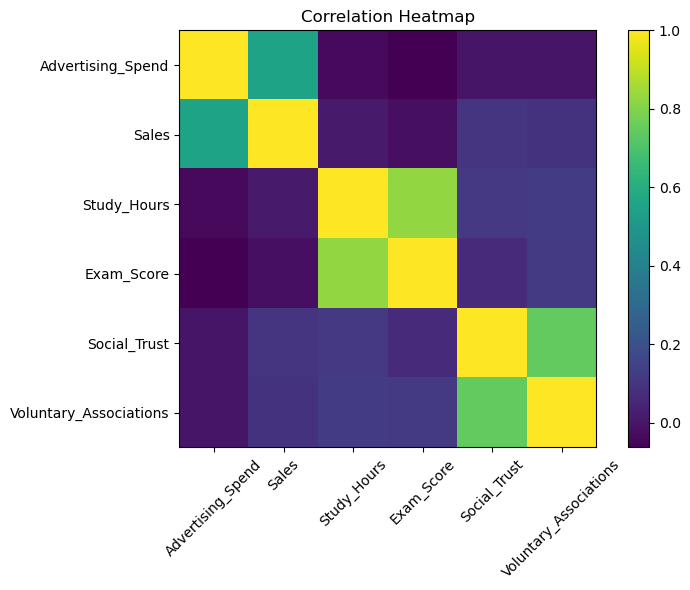


--- Key Correlations ---
Strongest Positive: 0.8294748677416668
Strongest Negative: -0.06308718482990985
Weakest (closest to 0): 0.09372200658058828


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Select numeric columns
numeric_df = df.select_dtypes(include=['number'])

# -----------------------------
# 1. Correlation Matrix
# -----------------------------
corr_matrix = numeric_df.corr()

print("Correlation Matrix:\n")
print(corr_matrix)

# -----------------------------
# 2. Heatmap Visualization
# -----------------------------
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix)

plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# -----------------------------
# 3. Strongest & Weakest Correlations
# -----------------------------

# Remove self-correlation (diagonal)
corr_matrix_no_diag = corr_matrix.where(~np.eye(corr_matrix.shape[0], dtype=bool))

# Flatten matrix
corr_pairs = corr_matrix_no_diag.unstack().dropna()

# Sort
sorted_corr = corr_pairs.sort_values()

# Weakest (closest to 0)
weakest = sorted_corr.iloc[len(sorted_corr)//2]

# Strongest positive
strongest_pos = sorted_corr.iloc[-1]

# Strongest negative
strongest_neg = sorted_corr.iloc[0]

print("\n--- Key Correlations ---")
print(f"Strongest Positive: {strongest_pos}")
print(f"Strongest Negative: {strongest_neg}")
print(f"Weakest (closest to 0): {weakest}")

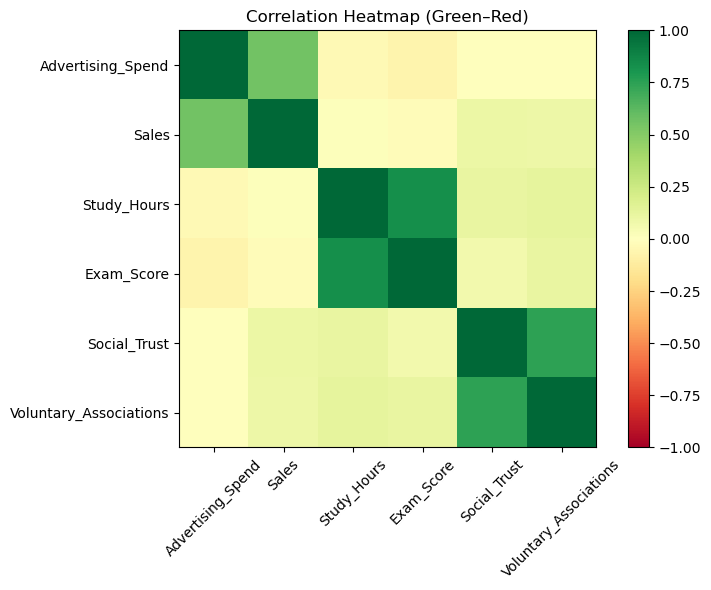

In [6]:
# Load data

numeric_df = df.select_dtypes(include=['number'])

# Correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(8,6))

plt.imshow(corr_matrix, cmap='RdYlGn', vmin=-1, vmax=1)

plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Heatmap (Green–Red)")
plt.tight_layout()
plt.show()

### Calculate the Spearman correlation between Study_Hours and Exam_Score. Explain why Spearman may be more appropriate in this case.

In [8]:
from scipy.stats import spearmanr
# Extract variables
x = df["Study_Hours"]
y = df["Exam_Score"]

# Spearman correlation
rho, p_value = spearmanr(x, y)

print("Spearman Correlation (rho):", rho)
print("P-value:", p_value)

Spearman Correlation (rho): 0.8363998829319153
P-value: 1.7619394897039723e-40


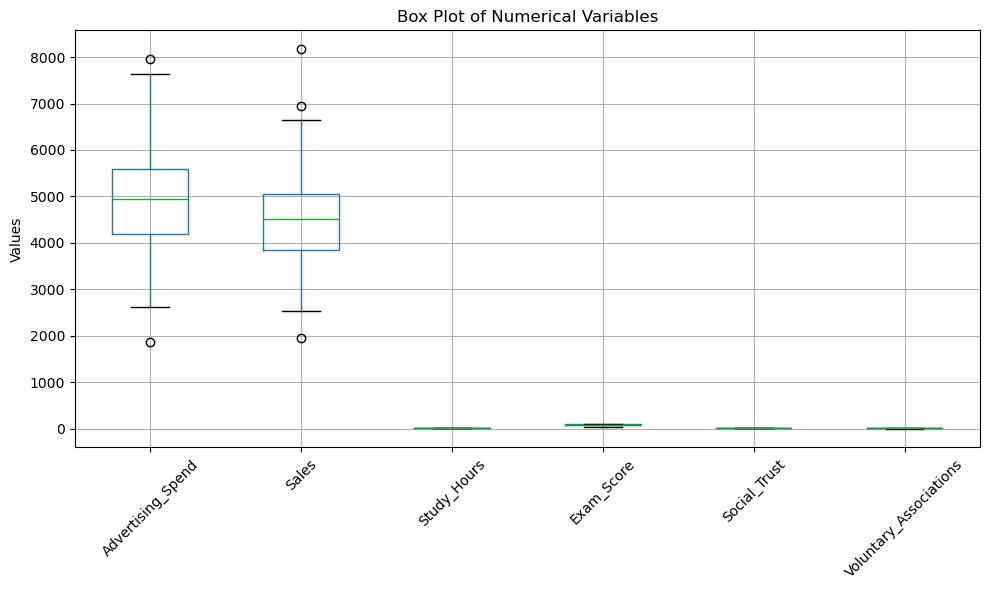

In [9]:
# Select numeric columns
numeric_df = df.select_dtypes(include=['number'])

# -----------------------------
# Box plot
# -----------------------------
plt.figure(figsize=(10, 6))

numeric_df.boxplot()

plt.title("Box Plot of Numerical Variables")
plt.xticks(rotation=45)
plt.ylabel("Values")

plt.tight_layout()
plt.show()

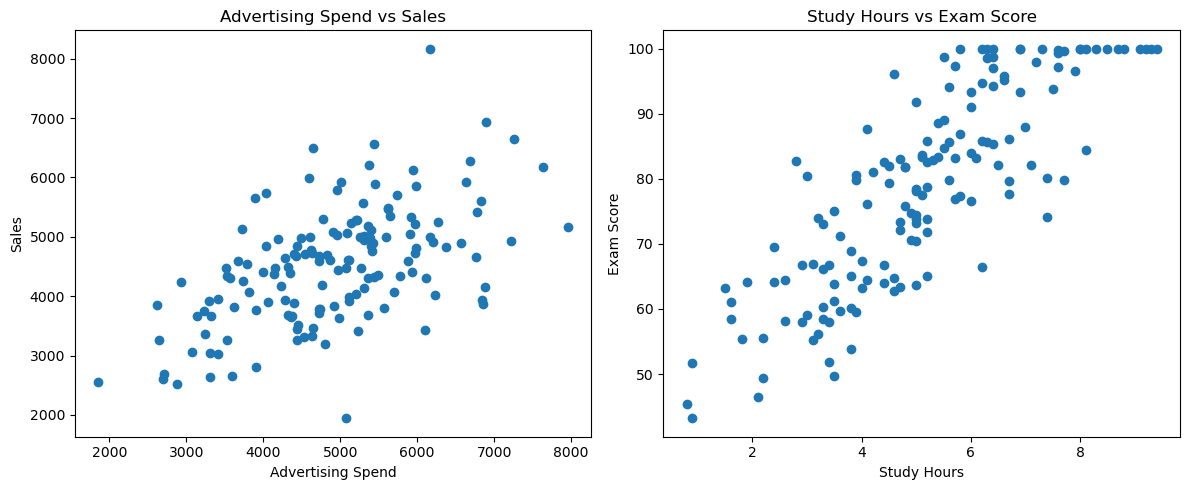

In [10]:
# -----------------------------
# Create scatterplots
# -----------------------------
plt.figure(figsize=(12, 5))

# (a) Advertising_Spend vs Sales
plt.subplot(1, 2, 1)
plt.scatter(df["Advertising_Spend"], df["Sales"])
plt.xlabel("Advertising Spend")
plt.ylabel("Sales")
plt.title("Advertising Spend vs Sales")

# (b) Study_Hours vs Exam_Score
plt.subplot(1, 2, 2)
plt.scatter(df["Study_Hours"], df["Exam_Score"])
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Study Hours vs Exam Score")

plt.tight_layout()
plt.show()

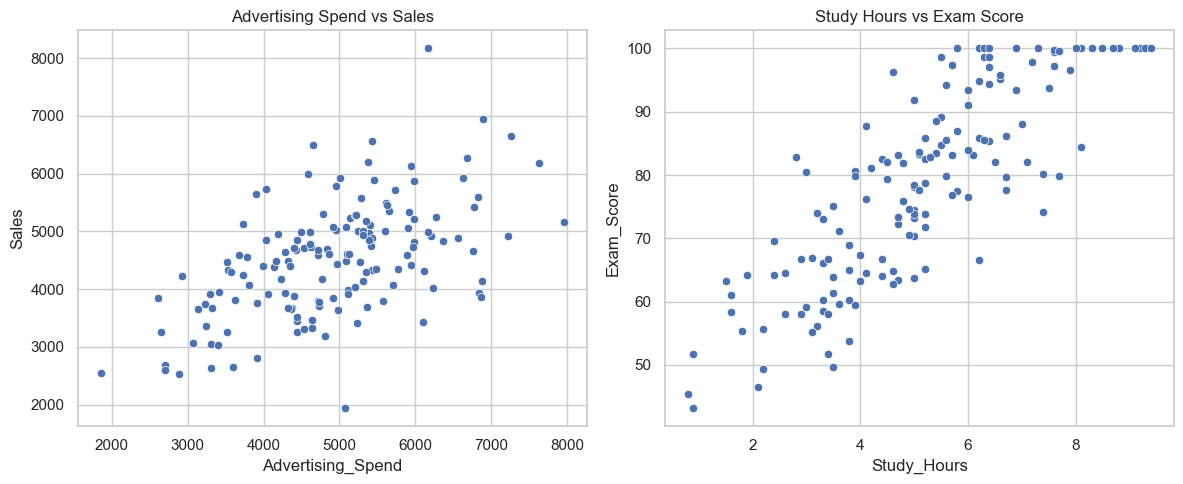

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("data/correlation_case_study_MP_1.csv")

# Set style
sns.set(style="whitegrid")

# -----------------------------
# Create scatterplots
# -----------------------------
plt.figure(figsize=(12, 5))

# (a) Advertising_Spend vs Sales
plt.subplot(1, 2, 1)
sns.scatterplot(
    data=df,
    x="Advertising_Spend",
    y="Sales"
)
plt.title("Advertising Spend vs Sales")

# (b) Study_Hours vs Exam_Score
plt.subplot(1, 2, 2)
sns.scatterplot(
    data=df,
    x="Study_Hours",
    y="Exam_Score"
)
plt.title("Study Hours vs Exam Score")

plt.tight_layout()
plt.show()

In [12]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr

# Load data
# df = pd.read_csv("data/correlation_case_study_MP_1.csv")

# -----------------------------
# Original Pearson correlation
# -----------------------------
r_original, p_original = pearsonr(df["Advertising_Spend"], df["Sales"])

# -----------------------------
# Introduce outlier
# -----------------------------
df_outlier = df.copy()

# Replace first value with extreme outlier
df_outlier.loc[0, "Advertising_Spend"] = 50000

# -----------------------------
# New Pearson correlation
# -----------------------------
r_new, p_new = pearsonr(df_outlier["Advertising_Spend"], df_outlier["Sales"])

# -----------------------------
# Results
# -----------------------------
print("Original Pearson r:", r_original)
print("Original p-value:", p_original)

print("\nAfter Outlier:")
print("New Pearson r:", r_new)
print("New p-value:", p_new)

Original Pearson r: 0.555523607700913
Original p-value: 1.6024409318960924e-13

After Outlier:
New Pearson r: 0.20172502220781385
New p-value: 0.013306754623863123
